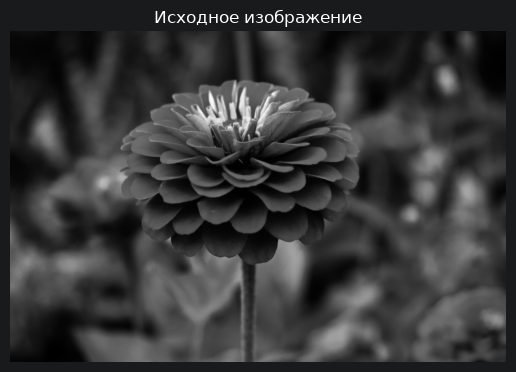

In [51]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity, mean_squared_error, peak_signal_noise_ratio

np.random.seed(0)
cv2.setRNGSeed(0)

image = cv2.imread('img.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.imshow(image_gray, cmap="gray")
plt.title("Исходное изображение")
plt.axis("off")
plt.show()

шум Гаусса

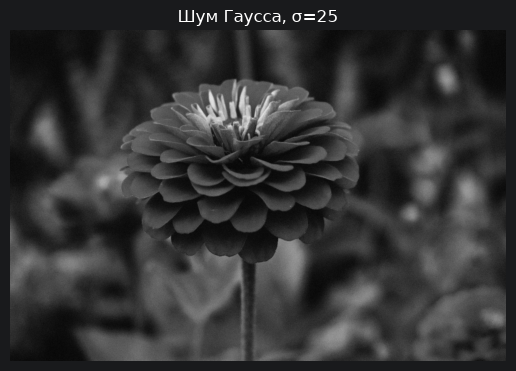

In [52]:
mean = 0
stddev = 25
noise_gauss = np.random.normal(mean, stddev, image_gray.shape)
image_noise_gauss = np.clip(image_gray.astype(np.float32) + noise_gauss, 0, 255).astype(np.uint8)

plt.imshow(image_noise_gauss, cmap="gray")
plt.title("Шум Гаусса, σ=25")
plt.axis("off")
plt.show()

постоянный шум

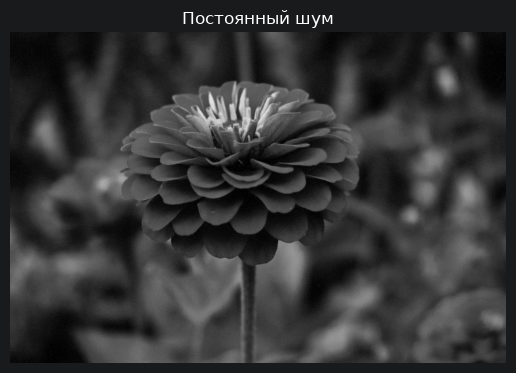

In [53]:
noise = np.random.randint(0, 101, size=(image_gray.shape[0], image_gray.shape[1]), dtype=int)
zeros_pixel = np.where(noise == 0)
ones_pixel = np.where(noise == 100)

image_sp = image_gray.copy()
image_sp[zeros_pixel] = 0
image_sp[ones_pixel] = 255

plt.imshow(image_sp, cmap="gray")
plt.title("Постоянный шум")
plt.axis("off")
plt.show()

вывод обоих зашумлённых изображений рядом

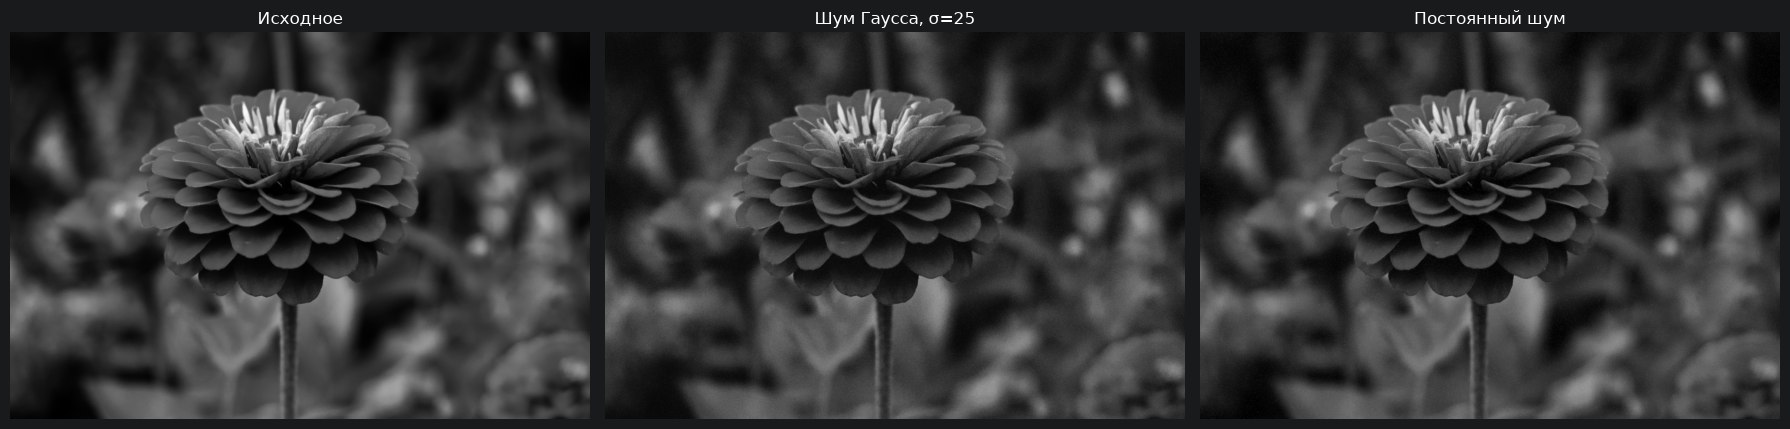

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(image_gray, cmap="gray"); axes[0].set_title("Исходное")
axes[1].imshow(image_noise_gauss, cmap="gray"); axes[1].set_title("Шум Гаусса, σ=25")
axes[2].imshow(image_sp, cmap="gray"); axes[2].set_title("Постоянный шум")
for ax in axes: ax.axis("off")
plt.tight_layout()
plt.show()

In [55]:
def metrics(ref, img):
    mse = mean_squared_error(ref, img)
    ssim = structural_similarity(ref, img)
    psnr = peak_signal_noise_ratio(ref, img, data_range=255)
    return mse, ssim, psnr

фильтры

In [56]:
def test_filters(noisy_image):
    results = {}

    for k in [3, 5, 7]:
        results[f"медианный k={k}"] = cv2.medianBlur(noisy_image, k)

    for k in [3, 5, 7]:
        for sigma in [0.5, 1.0, 1.5]:
            results[f"гаусса k={k} σ={sigma}"] = cv2.GaussianBlur(noisy_image, (k, k), sigma)

    for d in [5, 9]:
        for sc in [30, 75, 150]:
            results[f"билатериальный d={d} σc={sc}"] = cv2.bilateralFilter(noisy_image, d, sc, sc)

    for h in [5, 10, 15, 20]:
        results[f"НЛСРП h={h}"] = cv2.fastNlMeansDenoising(noisy_image, None, h, 7, 21)

    rows = []
    for name, img in results.items():
        mse, ssim, psnr = metrics(image_gray, img)
        rows.append((name, mse, ssim, psnr))

    rows.sort(key=lambda x: (x[2], x[3]), reverse=True)

    return results, rows

итог

In [57]:
print("=== Лучший фильтр для каждого типа шума ===\n")

g_name, g_mse, g_ssim, g_psnr = rows_gauss[0]
print(f"Шум Гаусса:     {g_name:25s} | MSE={g_mse:7.1f}  SSIM={g_ssim:.3f}  PSNR={g_psnr:5.2f}")

s_name, s_mse, s_ssim, s_psnr = rows_sp[0]
print(f"Постоянный шум: {s_name:25s} | MSE={s_mse:7.1f}  SSIM={s_ssim:.3f}  PSNR={s_psnr:5.2f}")

=== Лучший фильтр для каждого типа шума ===

Шум Гаусса:     NLM h=20                  | MSE=   22.5  SSIM=0.799  PSNR=34.62
Постоянный шум: Median k=3                | MSE=    7.7  SSIM=0.912  PSNR=39.26


показать лучшие результаты визуально

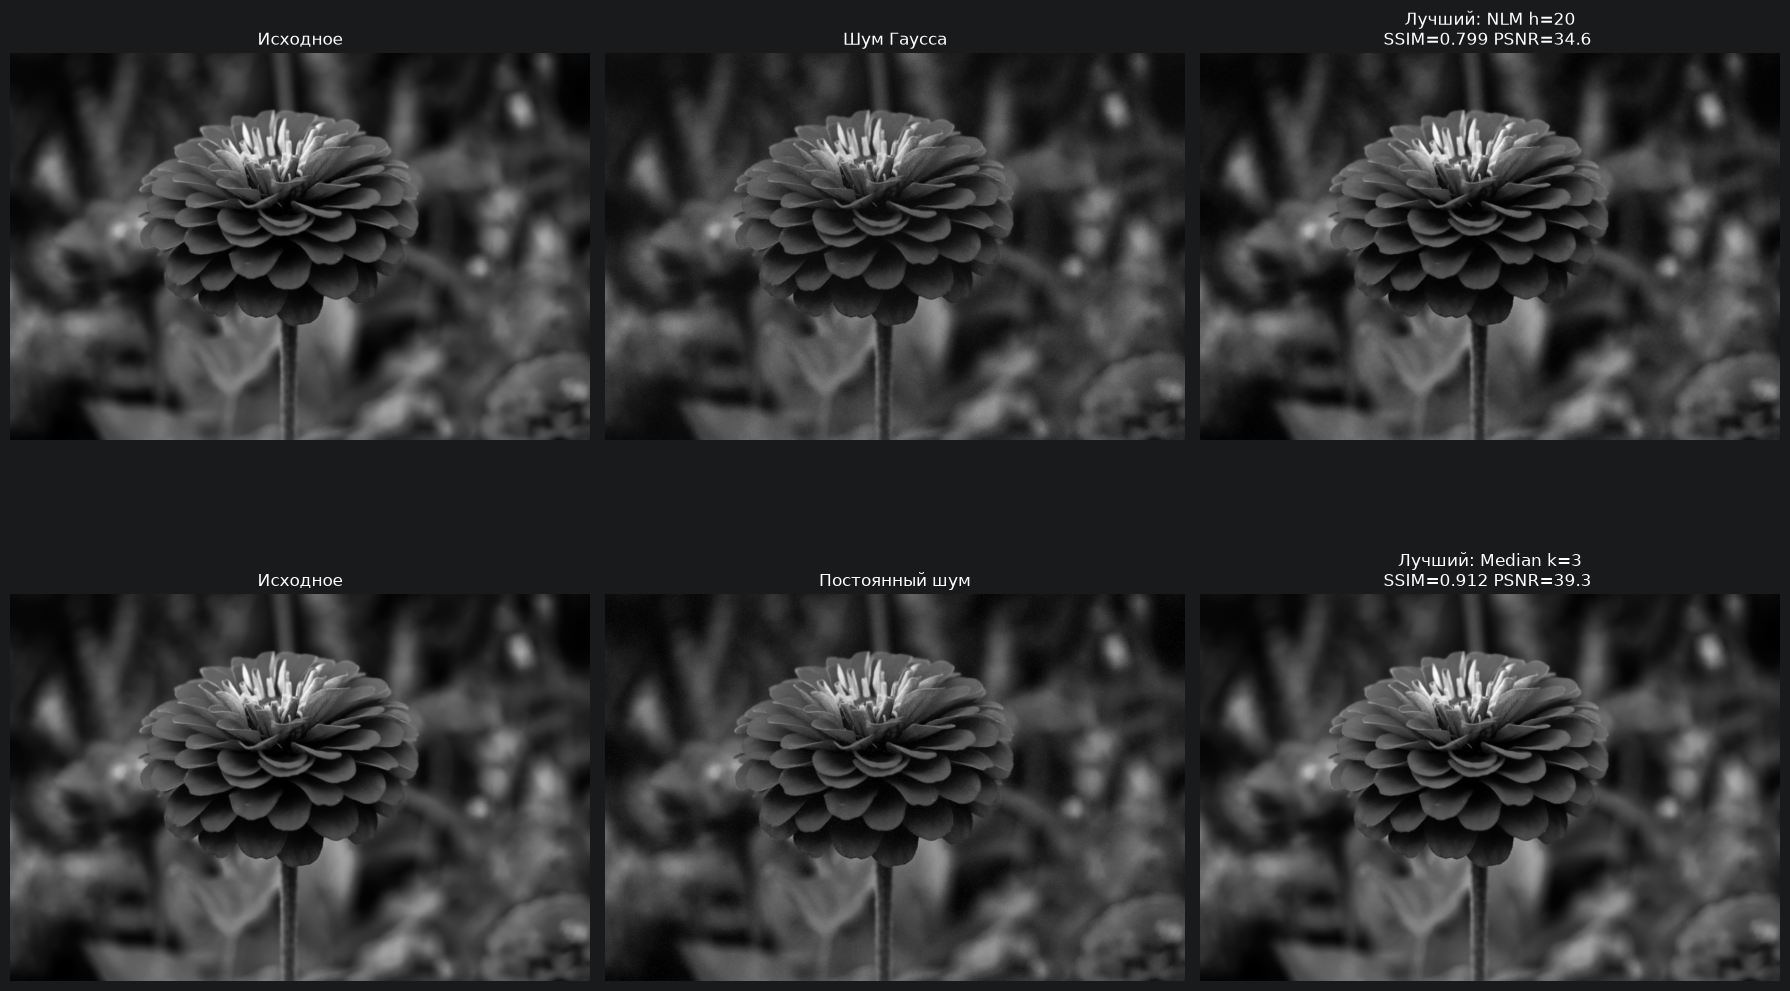

In [58]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

axes[0, 0].imshow(image_gray, cmap="gray"); axes[0, 0].set_title("Исходное")
axes[0, 1].imshow(image_noise_gauss, cmap="gray"); axes[0, 1].set_title("Шум Гаусса")
axes[0, 2].imshow(res_gauss[rows_gauss[0][0]], cmap="gray")
axes[0, 2].set_title(f"Лучший: {rows_gauss[0][0]}\nSSIM={rows_gauss[0][2]:.3f} PSNR={rows_gauss[0][3]:.1f} ")

axes[1, 0].imshow(image_gray, cmap="gray"); axes[1, 0].set_title("Исходное")
axes[1, 1].imshow(image_sp, cmap="gray"); axes[1, 1].set_title("Постоянный шум")
axes[1, 2].imshow(res_sp[rows_sp[0][0]], cmap="gray")
axes[1, 2].set_title(f"Лучший: {rows_sp[0][0]}\nSSIM={rows_sp[0][2]:.3f} PSNR={rows_sp[0][3]:.1f} ")

for ax in axes.flat: ax.axis("off")
plt.tight_layout()
plt.show()

сравнение по типам фильтров (лучший из каждого)

In [60]:
def best_per_type(rows):
    best = {}
    for name, mse, ssim, psnr in rows:
        base = name.split()[0]
        if base not in best:
            best[base] = (name, mse, ssim, psnr)
    for base, (name, mse, ssim, psnr) in best.items():
        print(f"{base:10s} | {name:25s} | MSE={mse:7.1f}  SSIM={ssim:.3f}  PSNR={psnr:5.2f} ")


print("=== Шум Гаусса: лучший из каждого типа ===")
best_per_type(rows_gauss)

print("\n=== Постоянный шум: лучший из каждого типа ===")
best_per_type(rows_sp)

=== Шум Гаусса: лучший из каждого типа ===
NLM        | NLM h=20                  | MSE=   22.5  SSIM=0.799  PSNR=34.62 
Bilateral  | Bilateral d=9 σc=150      | MSE=   27.9  SSIM=0.772  PSNR=33.67 
Median     | Median k=7                | MSE=   32.1  SSIM=0.729  PSNR=33.07 
Gauss      | Gauss k=7 σ=1.5           | MSE=   35.9  SSIM=0.721  PSNR=32.57 

=== Постоянный шум: лучший из каждого типа ===
Median     | Median k=3                | MSE=    7.7  SSIM=0.912  PSNR=39.26 
Bilateral  | Bilateral d=9 σc=150      | MSE=   16.9  SSIM=0.819  PSNR=35.84 
Gauss      | Gauss k=7 σ=1.5           | MSE=   29.3  SSIM=0.766  PSNR=33.46 
NLM        | NLM h=20                  | MSE=   64.2  SSIM=0.751  PSNR=30.06 
